# Ablation Study: Classical Baselines for Energy-Based Regularization

**Author:** David Strnadel  
**Date:** December 2025  
**Affiliation:** Faculty of Applied Informatics, Tomas Bata University in Zlin

---

## Purpose

This notebook implements **classical ablation baselines** to test whether the observed effects in QACGAN (high early-epoch class consistency) are:

1. **Specific to the VQE formulation**, or
2. **Replicable by any class-dependent auxiliary signal**

### Ablation Variants

| Variant | Description | Parameters | Tests |
|---------|-------------|------------|-------|
| **MLP-Energy** | `MLP(z, c) → scalar` architecture-matched to AngleProducer | ~47k | Is the effect from "any smooth class-dependent regularizer"? |
| **Learned Bias** | `bias[c]` - simple learned per-class scalar | 10 | Is the effect from "any class signal"? |
| **Random Noise** | Deterministic pseudo-random from z (class-independent) | 0 | Control: does any auxiliary gradient help? |
| **No Regularizer** | Pure ACGAN baseline | 0 | Reference baseline |

### Architecture-Matching Note (MLP-Energy)

MLP-Energy is **architecture-matched** (not just parameter-matched) to AngleProducer:
- Same input conditioning: `z * embedding(c)` element-wise multiplication
- Same embedding dimension: 100
- Same intermediate activations: ReLU
- Output transformation: Tanh (bounded to [-3, 3])
- Parameter difference vs AngleProducer: **7.6% fewer** (47,209 vs 51,064)

This tests whether the VQE's learned mapping provides unique value vs. a classical MLP with identical input structure.

### Hypothesis Under Test (H1)

> The observed acceleration of class consistency (99-100% accuracy within 5 epochs) is explainable purely by the presence of **any smooth class-dependent scalar regularizer** of similar architecture and gradient scale; the "quantum" character is not necessary.

**Support for H1:** If MLP-Energy replicates (i) fast class-accuracy, (ii) similar FID/IS behavior, and (iii) similar variance across seeds.  
**Falsification of H1:** If no reasonably comparable classical construction replicates the effect without substantially different tuning.

---

## Pre-Registered Analysis Protocol

### Fairness Conditions (held constant across all variants):
| Parameter | Value | Justification |
|-----------|-------|---------------|
| Epochs | 5 | Match QACGAN main experiments |
| Batch size | 64 (2×32 accumulation) | GPU memory constraint, **gradient accumulation implemented** |
| Optimizer | Adam | Standard for GANs |
| LR (G, D) | 2×10⁻⁴ | Matched to original QACGAN |
| β₁, β₂ | 0.5, 0.999 | GAN standard |
| λ_reg | 0.1 | Matched to QACGAN λ_vqe |
| Label smoothing | 0.9 | **Applied to both D AND G** (matching QACGAN) |
| Seeds | [42, 2025, 123, 456, 789] | 5 seeds, fixed across ALL variants |

### Training Protocol Alignment with QACGAN:
- **Gradient accumulation:** 2 micro-batches (32) → 1 effective batch (64)
- **G adversarial target:** Uses smoothed label (0.9), NOT 1.0 — matches QACGAN exactly
- **Loss scaling:** Divided by ACCUMULATION_STEPS before backward, restored for logging

### Primary Endpoints (evaluated at epoch 5):
| Endpoint | Definition | Sampling |
|----------|------------|----------|
| **Class Accuracy** | % correctly classified by external CNN | 500 samples, balanced (50/class) |
| **FID** | Fréchet Inception Distance vs MNIST train | 1000 samples |
| **IS** | Inception Score | 1000 samples |
| **LPIPS Diversity** | Mean pairwise within-class LPIPS distance | 20 samples/class × 10 classes |

### Statistical Analysis (pre-registered):
| Analysis | Method | Justification |
|----------|--------|---------------|
| Confidence intervals | Bootstrap, 10,000 resamples | Non-parametric, robust |
| Effect size | Cohen's d | Standardized comparison |
| Significance tests | Paired t-test (same seeds) | Reduces seed-induced variance |
| Multiple comparisons | Report unadjusted p-values + effect sizes | Exploratory ablation |

### Decision Criteria for "≈" (practical equivalence):
| Metric | Threshold δ | Justification |
|--------|-------------|---------------|
| Accuracy | ±3% | ~1 std expected from seed variance |
| FID | ±5.0 | ~15-20% of typical FID ~30 |
| IS | ±0.3 | ~15% of typical IS ~2.0 |
| LPIPS | ±0.05 | ~20% of expected range 0.15-0.30 |

**A ≈ B** if ALL of:
1. |mean_A - mean_B| < δ (within practical threshold)
2. 95% CI of (A - B) includes 0 (not statistically different)
3. |Cohen's d| < 0.5 (small-to-medium effect)

### Random Noise Reproducibility:
The Random Noise variant uses deterministic pseudo-random output based on latent z:
- Fixed projection matrix (buffer, not learned)
- Same z always produces same energy value
- Has gradient w.r.t. z (valid for backprop)
- Verified by: generate same z twice → same energy output

In [1]:
#@title Installation of Required Libraries

!pip install --upgrade pip -q
!pip install \
    torch \
    torchvision \
    torch-fidelity \
    scikit-image \
    ipywidgets \
    lpips \
    -q

print("✅ Installation complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 46.7 MB/s eta 0:00:00
✅ Installation complete!


In [2]:
#@title Imports and Setup

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import time
import shutil
import tempfile
from collections import defaultdict
import json

from torch_fidelity import calculate_metrics

try:
    import lpips
    LPIPS_AVAILABLE = True
except ImportError:
    LPIPS_AVAILABLE = False
    print("Warning: LPIPS not available. Intra-class diversity metrics will be skipped.")

print(f"PyTorch version: {torch.__version__}")
print(f"LPIPS available: {LPIPS_AVAILABLE}")

PyTorch version: 2.9.0+cu126
LPIPS available: True


In [3]:
#@title Device and Paths Configuration

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("GPU not available, using CPU.")

WORK_DIR = "/content/"
MNIST_DOWNLOAD_PATH = os.path.join(WORK_DIR, "MNIST_data")
MNIST_TRAIN_IMAGES_PATH = os.path.join(WORK_DIR, "MNIST_train_images_png")
CLASSIFIER_PATH = os.path.join(WORK_DIR, "mnist_classifier.pth")

# Output directories for each ablation variant
ABLATION_VARIANTS = ["mlp_energy", "learned_bias", "random_noise", "no_regularizer"]
OUTPUT_DIRS = {}
for variant in ABLATION_VARIANTS:
    OUTPUT_DIRS[variant] = {
        "images": os.path.join(WORK_DIR, f"ablation_{variant}_images"),
        "models": os.path.join(WORK_DIR, f"ablation_{variant}_models"),
        "logs": os.path.join(WORK_DIR, f"ablation_{variant}_logs.pkl")
    }
    os.makedirs(OUTPUT_DIRS[variant]["images"], exist_ok=True)
    os.makedirs(OUTPUT_DIRS[variant]["models"], exist_ok=True)

print(f"Working directory: {WORK_DIR}")
print(f"Ablation variants configured: {ABLATION_VARIANTS}")

GPU is available: NVIDIA A100-SXM4-80GB
Working directory: /content/
Ablation variants configured: ['mlp_energy', 'learned_bias', 'random_noise', 'no_regularizer']


In [4]:
#@title Hyperparameters (FAIRNESS CONDITIONS - DO NOT MODIFY)

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FAIRNESS CONDITIONS: These parameters are FIXED across all ablation runs    ║
# ║  Modifying any of these invalidates the comparison!                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# === EXPERIMENT CONFIGURATION ===
SEEDS = [42, 2025, 123, 456, 789]  # 5 seeds for statistical rigor (PRE-REGISTERED)
NUM_EPOCHS = 5  # Match QACGAN exploratory run

# === Model Parameters (FIXED) ===
Z_DIM = 100
NUM_CLASSES = 10
IMG_CHANNELS = 1
IMG_SIZE = 28

# === Regularization (FIXED - matches QACGAN's λ_VQE = 0.1) ===
LAMBDA_REG = 0.1
ENERGY_SCALE = 3.0  # Scale output to match VQE energy range [-3, 3]

# === Training (FIXED - identical to QACGAN) ===
EFFECTIVE_BATCH_SIZE = 64
MICRO_BATCH_SIZE = 32
ACCUMULATION_STEPS = EFFECTIVE_BATCH_SIZE // MICRO_BATCH_SIZE
LEARNING_RATE_G = 0.0002
LEARNING_RATE_D = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LABEL_SMOOTHING = 0.9

# === Evaluation (FIXED) ===
LOG_INTERVAL = 50
EVAL_INTERVAL = 1  # Evaluate every epoch for detailed tracking
NUM_SAMPLES_FOR_METRICS = 1000  # FID/IS
NUM_SAMPLES_FOR_ACCURACY = 500  # Classification
NUM_SAMPLES_FOR_DIVERSITY = 50  # Per class for LPIPS (50 samples → C(50,2)=1225 pairs)

# === Statistical Analysis (PRE-REGISTERED) ===
ALPHA = 0.05  # Significance level
BOOTSTRAP_SAMPLES = 10000  # For bootstrap CI
EQUIVALENCE_THRESHOLDS = {
    'accuracy': 3.0,   # ±3%
    'fid': 5.0,        # ±5.0
    'is': 0.3,         # ±0.3
    'lpips': 0.05      # ±0.05
}

print("="*70)
print("FAIRNESS CONDITIONS (PRE-REGISTERED - DO NOT MODIFY)")
print("="*70)
print(f"Seeds: {SEEDS}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Batch size: {EFFECTIVE_BATCH_SIZE}")
print(f"Learning rate (G, D): {LEARNING_RATE_G}")
print(f"λ_reg: {LAMBDA_REG}")
print(f"Energy scale: {ENERGY_SCALE}")
print(f"Label smoothing: {LABEL_SMOOTHING}")
print(f"Evaluation samples: FID/IS={NUM_SAMPLES_FOR_METRICS}, Acc={NUM_SAMPLES_FOR_ACCURACY}, LPIPS={NUM_SAMPLES_FOR_DIVERSITY}/class")
print("="*70)

FAIRNESS CONDITIONS (PRE-REGISTERED - DO NOT MODIFY)
Seeds: [42, 2025, 123, 456, 789]
Epochs: 5
Batch size: 64
Learning rate (G, D): 0.0002
λ_reg: 0.1
Energy scale: 3.0
Label smoothing: 0.9
Evaluation samples: FID/IS=1000, Acc=500, LPIPS=50/class


## Classical Regularizer Implementations

These modules replace the VQE energy computation with classical alternatives.

### Architecture Comparison (architecture-matched up to penultimate layer):

**Important:** We use the term **"architecture-matched"**, not "parameter-matched".
Both networks share identical structure up to the final layer.

```
AngleProducer (QACGAN):              MLP-Energy (Ablation):
────────────────────────────────     ────────────────────────────────
Embedding(10, 100)        [1,000]    Embedding(10, 100)        [1,000]
z * embedding (elem-wise)    [-]     z * embedding (elem-wise)    [-]
Linear(100 → 128) + ReLU [12,928]    Linear(100 → 128) + ReLU [12,928]
Linear(128 → 256) + ReLU [33,024]    Linear(128 → 256) + ReLU [33,024]
Linear(256 → 16) + Tanh   [4,112]    Linear(256 → 1) + Tanh      [257]
× π → 16 circuit params              × 3.0 → 1 energy scalar
────────────────────────────────     ────────────────────────────────
Total trainable: 51,064              Total trainable: 47,209
Difference: 3,855 params (7.6%)
```

**Rationale:** The 7.6% parameter difference is a **conservative choice**:
- If MLP-Energy (with fewer params) matches QACGAN → effect is clearly not from capacity
- If MLP-Energy underperforms → cannot exclude that larger MLP would help (but this supports H1)

In [5]:
#@title Classical Regularizer Modules

class MLPEnergyRegularizer(nn.Module):
    """
    MLP-based class-dependent energy regularizer.
    Maps (z, c) -> scalar energy value.

    Architecture-matched to AngleProducer up to penultimate layer:
    - Embedding(10, 100): 1,000 params
    - Linear(100 → 128): 12,928 params
    - Linear(128 → 256): 33,024 params
    - Linear(256 → 1): 257 params (vs 4,112 in AngleProducer)
    - Total: 47,209 params (vs 51,064 in AngleProducer, diff = 7.6%)

    Output scaled to [-3, 3] to match VQE energy range.
    """
    def __init__(self, z_dim=100, num_classes=10, hidden_dim=128):
        super().__init__()
        self.label_embedding = nn.Embedding(num_classes, z_dim)  # 1,000 params
        self.mlp = nn.Sequential(
            nn.Linear(z_dim, hidden_dim),           # 12,928 params
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim * 2),  # 33,024 params
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim * 2, 1),           # 257 params
            nn.Tanh()  # Output in [-1, 1]
        )
        self.scale = ENERGY_SCALE  # 3.0 - match VQE energy range

    def forward(self, z, class_labels):
        embedded = self.label_embedding(class_labels)
        conditioned = z * embedded  # Element-wise conditioning (identical to AngleProducer)
        energy = self.mlp(conditioned) * self.scale
        return energy.squeeze(-1)


class LearnedBiasRegularizer(nn.Module):
    """
    Simple learned per-class bias (minimal baseline).
    Tests if just having ANY class signal is enough.

    This is the minimal class-dependent regularizer:
    just 10 learned scalars, one per class.

    Params: 10 (vs 47,209 in MLP-Energy)
    """
    def __init__(self, num_classes=10):
        super().__init__()
        # Initialize with values in VQE energy range
        self.class_biases = nn.Parameter(torch.randn(num_classes) * 0.5)  # ~[-1.5, 1.5]

    def forward(self, z, class_labels):
        # z is ignored - this is purely class-dependent
        return self.class_biases[class_labels]


class RandomNoiseRegularizer(nn.Module):
    """
    Class-independent random noise regularizer (control condition).

    IMPORTANT: This is deterministic given the seed and has gradients through z.
    - Uses z to generate pseudo-random but deterministic output
    - Same z always produces same "random" energy
    - Has gradient w.r.t. z (unlike true random noise)
    - Output scaled to [-3, 3] to match other regularizers

    This tests if ANY auxiliary gradient signal helps, regardless of class.
    """
    def __init__(self, z_dim=100, scale=None):
        super().__init__()
        self.scale = scale if scale is not None else ENERGY_SCALE
        # Fixed random projection (not learned, but deterministic)
        self.register_buffer('projection', torch.randn(z_dim, 1) * 0.1)

    def forward(self, z, class_labels):
        # Deterministic "random" value based on z (class_labels ignored)
        # This has gradient w.r.t. z, making it a valid regularizer
        energy = torch.tanh(z @ self.projection).squeeze(-1) * self.scale
        return energy


class NoRegularizer(nn.Module):
    """
    No regularization (pure ACGAN baseline).
    Always returns zero energy - no auxiliary gradient signal.

    This is the true baseline: ACGAN without any energy term.
    """
    def __init__(self):
        super().__init__()
        # No parameters

    def forward(self, z, class_labels):
        batch_size = z.size(0)
        return torch.zeros(batch_size, device=z.device, requires_grad=False)


# Factory function
def get_regularizer(variant_name, z_dim=100, num_classes=10):
    """Factory function to create regularizer by name."""
    if variant_name == "mlp_energy":
        return MLPEnergyRegularizer(z_dim, num_classes)
    elif variant_name == "learned_bias":
        return LearnedBiasRegularizer(num_classes)
    elif variant_name == "random_noise":
        return RandomNoiseRegularizer(z_dim)
    elif variant_name == "no_regularizer":
        return NoRegularizer()
    else:
        raise ValueError(f"Unknown regularizer variant: {variant_name}")


# Verify parameter counts
print("="*60)
print("REGULARIZER PARAMETER COUNTS")
print("="*60)
for name in ABLATION_VARIANTS:
    reg = get_regularizer(name)
    params = sum(p.numel() for p in reg.parameters())
    buffers = sum(b.numel() for b in reg.buffers())
    print(f"{name:20s}: {params:,} trainable params, {buffers:,} buffer elements")

print("-"*60)
print("Reference: AngleProducer (QACGAN) has 51,064 trainable params")
print("MLP-Energy difference from AngleProducer: 7.6% fewer params")
print("="*60)

REGULARIZER PARAMETER COUNTS
mlp_energy          : 47,209 trainable params, 0 buffer elements
learned_bias        : 10 trainable params, 0 buffer elements
random_noise        : 0 trainable params, 100 buffer elements
no_regularizer      : 0 trainable params, 0 buffer elements
------------------------------------------------------------
Reference: AngleProducer (QACGAN) has 51,064 trainable params
MLP-Energy difference from AngleProducer: 7.6% fewer params


In [6]:
#@title Generator with Pluggable Regularizer

class AblationGenerator(nn.Module):
    """
    ACGAN Generator with pluggable energy regularizer.

    This is the same architecture as HybridGenerator but with
    the VQE module replaced by a configurable regularizer.
    """
    def __init__(self, z_dim, num_classes, img_channels, regularizer_module, lambda_reg=0.1):
        super().__init__()

        self.z_dim = z_dim
        self.num_classes = num_classes
        self.img_channels = img_channels
        self.lambda_reg = lambda_reg

        # Classical generator (identical to QACGAN)
        self.label_embedding = nn.Embedding(num_classes, num_classes)
        self.input_layer = nn.Linear(z_dim + num_classes, 256 * 7 * 7)

        self.main_cnn = nn.Sequential(
            nn.BatchNorm2d(256),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, img_channels, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

        # Pluggable regularizer
        self.regularizer = regularizer_module

    def forward(self, z, class_labels):
        # Image generation (classical path)
        embedded = self.label_embedding(class_labels)
        gen_input = torch.cat((z, embedded), dim=1)
        features_flat = self.input_layer(gen_input)
        features_map = features_flat.view(-1, 256, 7, 7)
        img = self.main_cnn(features_map)

        # Energy regularization
        energy = self.regularizer(z, class_labels)

        return img, energy


class Discriminator(nn.Module):
    """
    ACGAN Discriminator (identical to QACGAN).
    """
    def __init__(self, num_classes=10, img_channels=1):
        super().__init__()

        self.main_conv = nn.Sequential(
            nn.Conv2d(img_channels, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.adv_layer = nn.Sequential(
            nn.Linear(256 * 4 * 4, 1),
            nn.Sigmoid()
        )

        self.aux_layer = nn.Linear(256 * 4 * 4, num_classes)

    def forward(self, img):
        features = self.main_conv(img)
        flat = features.view(features.size(0), -1)
        validity = self.adv_layer(flat)
        class_logits = self.aux_layer(flat)
        return validity, class_logits


def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
    elif classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

print("✅ Generator and Discriminator defined.")

✅ Generator and Discriminator defined.


In [14]:
#@title External Classifier (for evaluation)
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  IMPORTANT: Upload mnist_classifier.pth before running experiments!          ║
# ║  This classifier is REQUIRED for the primary endpoint (Class Accuracy).      ║
# ║  Source: hybrid_acgan_results_RUN1/mnist_classifier.pth (from GitHub repo)   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# For Colab: Upload the classifier file
# Option 1: Manual upload
#   from google.colab import files
#   uploaded = files.upload()  # Select mnist_classifier.pth
#   !mv mnist_classifier.pth {WORK_DIR}/

# Option 2: Download from GitHub (if repo is public)
#   !wget -O {WORK_DIR}/mnist_classifier.pth "https://github.com/o0SilentStorm0o/VQE-in-GAN/raw/main/hybrid_acgan_results_RUN1/mnist_classifier.pth"

class MnistClassifier(nn.Module):
    """
    External MNIST classifier for evaluating class consistency.
    Architecture: Simple CNN trained on MNIST to ~99% accuracy.

    This is the SAME classifier used in QACGAN evaluation,
    ensuring apple-to-apple comparison.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc_block = nn.Sequential(
            nn.Linear(64 * 7 * 7, 1024),
            nn.ReLU(),
            nn.Linear(1024, num_classes))

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = x.view(x.size(0), -1)
        return self.fc_block(x)

# Load classifier
external_classifier = None
if os.path.exists(CLASSIFIER_PATH):
    external_classifier = MnistClassifier().to(device)
    external_classifier.load_state_dict(torch.load(CLASSIFIER_PATH, map_location=device))
    external_classifier.eval()
    print(f"✅ External classifier loaded from {CLASSIFIER_PATH}")
else:
    print(f"⚠️ Classifier not found at {CLASSIFIER_PATH}")
    print("   Please upload mnist_classifier.pth to compute accuracy metrics.")
    print("   Option 1: Manual upload via Colab files.upload()")
    print("   Option 2: wget from GitHub repo")
    print("   Without classifier, Class Accuracy will be None!")

✅ External classifier loaded from /content/mnist_classifier.pth


In [8]:
#@title Data Preparation

def save_mnist_as_images(dataset_path_root, output_dir):
    """
    Save MNIST training images as PNGs for FID computation.
    Images are resized to 299x299 and converted to RGB for Inception model.
    """
    from PIL import Image

    num_mnist_train = 60000
    if os.path.exists(output_dir):
        num_files = len([f for f in os.listdir(output_dir) if f.endswith('.png')])
        if num_files >= num_mnist_train:
            print(f"MNIST PNGs already exist in {output_dir}")
            return True
        shutil.rmtree(output_dir)

    os.makedirs(output_dir, exist_ok=True)
    print(f"Generating MNIST PNGs (299x299 RGB) to {output_dir}...")

    # Load raw MNIST without normalization
    mnist_dataset = datasets.MNIST(root=dataset_path_root, train=True, download=True, transform=None)

    for i, (image, label) in enumerate(mnist_dataset):
        # image is PIL Image (28x28 grayscale)
        # Convert to RGB
        image_rgb = image.convert('RGB')
        # Resize to 299x299 for Inception
        image_resized = image_rgb.resize((299, 299), Image.BILINEAR)
        # Save
        image_resized.save(os.path.join(output_dir, f"mnist_train_{i:05d}.png"))
        if (i + 1) % 10000 == 0:
            print(f"  Saved {i + 1}/{len(mnist_dataset)} images...")
    print(f"✅ Saved {len(mnist_dataset)} MNIST PNGs (299x299 RGB).")
    return True

# Prepare data
save_mnist_as_images(MNIST_DOWNLOAD_PATH, MNIST_TRAIN_IMAGES_PATH)

transform_train = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_dataset = datasets.MNIST(root=MNIST_DOWNLOAD_PATH, train=True, download=False, transform=transform_train)
train_loader = DataLoader(train_dataset, batch_size=MICRO_BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
print(f"✅ Training data loaded: {len(train_dataset)} samples")

Generating MNIST PNGs (299x299 RGB) to /content/MNIST_train_images_png...


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 337kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


  Saved 10000/60000 images...
  Saved 20000/60000 images...
  Saved 30000/60000 images...
  Saved 40000/60000 images...
  Saved 50000/60000 images...
  Saved 60000/60000 images...
✅ Saved 60000 MNIST PNGs (299x299 RGB).
✅ Training data loaded: 60000 samples


In [20]:
#@title Evaluation Functions (with LPIPS Diversity Protocol)

def compute_accuracy(generator, classifier, num_samples, device):
    """Compute classification accuracy on generated samples."""
    if classifier is None:
        return None

    generator.eval()
    classifier.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        samples_per_class = num_samples // NUM_CLASSES
        for c in range(NUM_CLASSES):
            z = torch.randn(samples_per_class, Z_DIM, device=device)
            labels = torch.full((samples_per_class,), c, dtype=torch.long, device=device)
            imgs, _ = generator(z, labels)
            preds = classifier(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += samples_per_class

    generator.train()
    return 100.0 * correct / total


def compute_fid_is(generator, num_samples, ref_path, device):
    """
    Compute FID and Inception Score using BALANCED sampling.

    Protocol (PRE-REGISTERED):
    - num_samples is divided equally across 10 classes
    - Each class gets num_samples // 10 samples
    - This eliminates class-distribution bias between runs

    NOTE: Images are resized to 299x299 and converted to RGB for Inception model.
    """
    from torchvision.transforms import functional as TF
    from PIL import Image

    generator.eval()
    samples_per_class = num_samples // NUM_CLASSES

    with tempfile.TemporaryDirectory() as tmpdir:
        with torch.no_grad():
            img_idx = 0
            for c in range(NUM_CLASSES):
                for _ in range(samples_per_class):
                    z = torch.randn(1, Z_DIM, device=device)
                    label = torch.tensor([c], dtype=torch.long, device=device)
                    img, _ = generator(z, label)

                    # Convert to PIL, resize to 299x299, convert to RGB (Inception requirement)
                    img_np = img.squeeze(0).cpu()
                    # Denormalize from [-1,1] to [0,1]
                    img_np = (img_np + 1) / 2
                    img_np = img_np.clamp(0, 1)
                    # Convert to PIL Image
                    img_pil = TF.to_pil_image(img_np)
                    # Convert grayscale to RGB
                    img_pil = img_pil.convert('RGB')
                    # Resize to 299x299 for Inception
                    img_pil = img_pil.resize((299, 299), Image.BILINEAR)
                    # Save
                    img_pil.save(os.path.join(tmpdir, f"gen_{img_idx:05d}.png"))
                    img_idx += 1

        # DEBUG: Verify generated images
        gen_files = [f for f in os.listdir(tmpdir) if f.endswith('.png')]
        if gen_files:
            sample_img = Image.open(os.path.join(tmpdir, gen_files[0]))
            print(f"  [FID Debug] Generated: {len(gen_files)} files, sample size={sample_img.size}, mode={sample_img.mode}")

        try:
            metrics = calculate_metrics(
                input1=tmpdir,
                input2=ref_path,
                cuda=(device.type == 'cuda'),
                fid=True,
                isc=True,
                verbose=False
            )
            fid = metrics.get('frechet_inception_distance', None)
            isc = metrics.get('inception_score_mean', None)
        except Exception as e:
            print(f"Error computing metrics: {e}")
            import traceback
            traceback.print_exc()
            fid, isc = None, None

    generator.train()
    return fid, isc


def compute_intra_class_diversity(generator, num_samples_per_class, device, lpips_model):
    """
    Compute intra-class diversity using LPIPS.

    Protocol (PRE-REGISTERED):
    1. For each class c ∈ {0,...,9}:
       - Generate N samples with label c
       - Compute all pairwise LPIPS distances: C(N,2) pairs
       - Mean pairwise distance for class c
    2. Return: mean across all 10 classes

    Interpretation:
    - Low LPIPS (< 0.1): Likely mode collapse / prototype generation
    - Medium LPIPS (0.1-0.3): Healthy diversity
    - High LPIPS (> 0.3): Possibly too much variance / noise

    NOTE: Images are resized to 64x64 for LPIPS (AlexNet requires >= 64x64)
    """
    if lpips_model is None:
        return None

    generator.eval()
    lpips_model.eval()
    class_diversities = []

    # LPIPS requires images >= 64x64 for AlexNet backbone
    resize_for_lpips = torch.nn.Upsample(size=(64, 64), mode='bilinear', align_corners=False)

    with torch.no_grad():
        for c in range(NUM_CLASSES):
            # Generate N samples for class c
            z = torch.randn(num_samples_per_class, Z_DIM, device=device)
            labels = torch.full((num_samples_per_class,), c, dtype=torch.long, device=device)
            imgs, _ = generator(z, labels)

            # LPIPS expects 3-channel images in [-1, 1]
            # Our images are 1-channel (28x28), so:
            # 1. Repeat to 3 channels
            # 2. Resize to 64x64 for AlexNet
            imgs_3ch = imgs.repeat(1, 3, 1, 1)
            imgs_resized = resize_for_lpips(imgs_3ch)

            # Compute pairwise LPIPS distances
            # For efficiency, sample up to 20 images (C(20,2) = 190 pairs)
            n_for_pairs = min(20, num_samples_per_class)
            distances = []

            for i in range(n_for_pairs):
                for j in range(i + 1, n_for_pairs):
                    d = lpips_model(imgs_resized[i:i+1], imgs_resized[j:j+1])
                    distances.append(d.item())

            if distances:
                class_diversities.append(np.mean(distances))

    generator.train()

    if class_diversities:
        return np.mean(class_diversities)
    return None


def compute_all_metrics(generator, classifier, lpips_model, ref_path, device):
    """Compute all metrics for a single evaluation."""
    accuracy = compute_accuracy(generator, classifier, NUM_SAMPLES_FOR_ACCURACY, device)
    fid, isc = compute_fid_is(generator, NUM_SAMPLES_FOR_METRICS, ref_path, device)
    diversity = compute_intra_class_diversity(generator, NUM_SAMPLES_FOR_DIVERSITY, device, lpips_model)

    return {
        'accuracy': accuracy,
        'fid': fid,
        'is': isc,
        'lpips_diversity': diversity
    }

print("✅ Evaluation functions defined.")
print(f"   - Accuracy: {NUM_SAMPLES_FOR_ACCURACY} samples")
print(f"   - FID/IS: {NUM_SAMPLES_FOR_METRICS} samples")
print(f"   - LPIPS: {NUM_SAMPLES_FOR_DIVERSITY} samples/class × 10 classes")

✅ Evaluation functions defined.
   - Accuracy: 500 samples
   - FID/IS: 1000 samples
   - LPIPS: 50 samples/class × 10 classes


In [21]:
#@title Training Function (with LPIPS tracking)

# Initialize LPIPS model once (global)
lpips_model = None
if LPIPS_AVAILABLE:
    try:
        lpips_model = lpips.LPIPS(net='alex').to(device)
        lpips_model.eval()
        print("✅ LPIPS model loaded (AlexNet backbone)")
    except Exception as e:
        print(f"⚠️ Failed to load LPIPS: {e}")
        lpips_model = None


def train_ablation_variant(variant_name, seed, num_epochs=NUM_EPOCHS):
    """
    Train a single ablation variant with a specific seed.
    Returns training logs with metrics per epoch.

    FAIRNESS: All hyperparameters are fixed (see Hyperparameters cell).
    """
    print(f"\n{'='*70}")
    print(f"Training: {variant_name.upper()} | Seed: {seed}")
    print(f"{'='*70}")

    # Set seed for reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Create models
    regularizer = get_regularizer(variant_name, Z_DIM, NUM_CLASSES)
    generator = AblationGenerator(Z_DIM, NUM_CLASSES, IMG_CHANNELS, regularizer, LAMBDA_REG).to(device)
    discriminator = Discriminator(NUM_CLASSES, IMG_CHANNELS).to(device)

    generator.apply(weights_init)
    discriminator.apply(weights_init)

    # Count parameters
    gen_params = sum(p.numel() for p in generator.parameters() if p.requires_grad)
    reg_params = sum(p.numel() for p in regularizer.parameters() if p.requires_grad)
    print(f"Generator params: {gen_params:,} (regularizer: {reg_params:,})")

    # Optimizers (FIXED - fairness condition)
    optimizer_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE_G, betas=(BETA1, BETA2))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE_D, betas=(BETA1, BETA2))

    # Loss functions
    adversarial_loss = nn.BCELoss()
    auxiliary_loss = nn.CrossEntropyLoss()

    # Training logs
    logs = {
        'variant': variant_name,
        'seed': seed,
        'epochs': [],
        'accuracy': [],
        'fid': [],
        'is': [],
        'lpips_diversity': [],  # NEW: track intra-class diversity
        'g_loss': [],
        'd_loss': [],
        'energy_mean': [],
        'energy_std': [],
        'time_per_epoch': []
    }

    # Fixed noise for visualization
    fixed_z = torch.randn(NUM_CLASSES * 5, Z_DIM, device=device)
    fixed_labels = torch.tensor([c for c in range(NUM_CLASSES) for _ in range(5)], device=device)

    # Training loop with GRADIENT ACCUMULATION (matching QACGAN protocol)
    for epoch in range(1, num_epochs + 1):
        epoch_start = time.time()
        g_losses, d_losses, energies = [], [], []

        # Zero gradients at start of accumulation
        optimizer_G.zero_grad()
        optimizer_D.zero_grad()

        for i, (real_imgs, real_labels) in enumerate(train_loader):
            batch_size = real_imgs.size(0)
            real_imgs = real_imgs.to(device)
            real_labels = real_labels.to(device)

            # Labels for adversarial loss (with smoothing - FIXED)
            # NOTE: Same smoothed target (0.9) used for BOTH D and G (matching QACGAN)
            valid = torch.full((batch_size, 1), LABEL_SMOOTHING, device=device)
            fake_target = torch.zeros((batch_size, 1), device=device)

            # -----------------
            # Train Generator
            # -----------------
            z = torch.randn(batch_size, Z_DIM, device=device)
            gen_labels = torch.randint(0, NUM_CLASSES, (batch_size,), device=device)
            gen_imgs, energy = generator(z, gen_labels)

            validity, pred_labels = discriminator(gen_imgs)

            # FIXED: Use same smoothed target (valid=0.9) as QACGAN, not ones
            g_adv = adversarial_loss(validity, valid)
            g_aux = auxiliary_loss(pred_labels, gen_labels)
            g_energy = LAMBDA_REG * energy.mean()  # Energy regularization (FIXED λ)

            # Scale loss for gradient accumulation
            g_loss = (g_adv + g_aux + g_energy) / ACCUMULATION_STEPS
            g_loss.backward()

            # ---------------------
            # Train Discriminator
            # ---------------------
            # Real images
            real_validity, real_pred = discriminator(real_imgs)
            d_real_adv = adversarial_loss(real_validity, valid)
            d_real_aux = auxiliary_loss(real_pred, real_labels)

            # Fake images
            fake_validity, fake_pred = discriminator(gen_imgs.detach())
            d_fake_adv = adversarial_loss(fake_validity, fake_target)
            d_fake_aux = auxiliary_loss(fake_pred, gen_labels)

            # Scale loss for gradient accumulation
            d_loss = ((d_real_adv + d_fake_adv) / 2 + (d_real_aux + d_fake_aux) / 2) / ACCUMULATION_STEPS
            d_loss.backward()

            # Gradient accumulation: step only every ACCUMULATION_STEPS
            if (i + 1) % ACCUMULATION_STEPS == 0:
                optimizer_G.step()
                optimizer_D.step()
                optimizer_G.zero_grad()
                optimizer_D.zero_grad()

            # Log (scale back for reporting)
            g_losses.append(g_loss.item() * ACCUMULATION_STEPS)
            d_losses.append(d_loss.item() * ACCUMULATION_STEPS)
            energies.append(energy.mean().item())

        epoch_time = time.time() - epoch_start

        # ===== EVALUATION (all metrics) =====
        accuracy = compute_accuracy(generator, external_classifier, NUM_SAMPLES_FOR_ACCURACY, device)
        fid, isc = compute_fid_is(generator, NUM_SAMPLES_FOR_METRICS, MNIST_TRAIN_IMAGES_PATH, device)
        diversity = compute_intra_class_diversity(generator, NUM_SAMPLES_FOR_DIVERSITY, device, lpips_model)

        # Log results
        logs['epochs'].append(epoch)
        logs['accuracy'].append(accuracy)
        logs['fid'].append(fid)
        logs['is'].append(isc)
        logs['lpips_diversity'].append(diversity)
        logs['g_loss'].append(np.mean(g_losses))
        logs['d_loss'].append(np.mean(d_losses))
        logs['energy_mean'].append(np.mean(energies))
        logs['energy_std'].append(np.std(energies))
        logs['time_per_epoch'].append(epoch_time)

        # Print progress
        lpips_str = f"{diversity:.3f}" if diversity else "N/A"
        print(f"Epoch {epoch}/{num_epochs} | "
              f"Acc: {accuracy:.1f}% | "
              f"FID: {fid:.2f} | "
              f"IS: {isc:.2f} | "
              f"LPIPS: {lpips_str} | "
              f"Time: {epoch_time:.1f}s")

        # Save samples
        generator.eval()
        with torch.no_grad():
            sample_imgs, _ = generator(fixed_z, fixed_labels)
            save_image(sample_imgs,
                      os.path.join(OUTPUT_DIRS[variant_name]["images"], f"seed{seed}_epoch{epoch:02d}.png"),
                      nrow=5, normalize=True)
        generator.train()

    # Save final model
    torch.save(generator.state_dict(),
               os.path.join(OUTPUT_DIRS[variant_name]["models"], f"generator_seed{seed}.pth"))

    # Print summary for this run
    print(f"\n--- Run complete: {variant_name} seed={seed} ---")
    print(f"Final Accuracy: {logs['accuracy'][-1]:.1f}%")
    print(f"Final FID: {logs['fid'][-1]:.2f}")
    print(f"Final IS: {logs['is'][-1]:.2f}")
    print(f"Final LPIPS: {logs['lpips_diversity'][-1]:.3f}" if logs['lpips_diversity'][-1] else "Final LPIPS: N/A")
    print(f"Total time: {sum(logs['time_per_epoch']):.1f}s")

    return logs

print("✅ Training function defined with full metrics tracking.")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
✅ LPIPS model loaded (AlexNet backbone)
✅ Training function defined with full metrics tracking.


In [13]:
#@title 🧪 SANITY CHECK (Run Before Full Experiment)
# Purpose: Verify training protocol is correct before spending hours on full run
# Config: 1 variant × 1 seed × 1 epoch, minimal evaluation

SANITY_CHECK = True  # Set to False to skip

if SANITY_CHECK:
    print("="*70)
    print("🧪 SANITY CHECK MODE")
    print("="*70)
    print("Config: no_regularizer × seed=42 × 1 epoch")
    print("Verifying: gradient accumulation, label smoothing, checkpointing")
    print("="*70)

    # Temporarily override for sanity check
    _orig_num_samples_acc = NUM_SAMPLES_FOR_ACCURACY
    _orig_num_samples_metrics = NUM_SAMPLES_FOR_METRICS
    NUM_SAMPLES_FOR_ACCURACY = 100  # 10/class, fast
    NUM_SAMPLES_FOR_METRICS = 100   # 10/class, fast

    # Custom sanity training function with extra logging
    def sanity_train(variant_name="no_regularizer", seed=42, num_epochs=1):
        print(f"\n{'='*70}")
        print(f"SANITY Training: {variant_name.upper()} | Seed: {seed}")
        print(f"{'='*70}")

        # Set seed
        torch.manual_seed(seed)
        np.random.seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        # Create models
        regularizer = get_regularizer(variant_name, Z_DIM, NUM_CLASSES)
        generator = AblationGenerator(Z_DIM, NUM_CLASSES, IMG_CHANNELS, regularizer, LAMBDA_REG).to(device)
        discriminator = Discriminator(NUM_CLASSES, IMG_CHANNELS).to(device)
        generator.apply(weights_init)
        discriminator.apply(weights_init)

        # Optimizers
        optimizer_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE_G, betas=(BETA1, BETA2))
        optimizer_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE_D, betas=(BETA1, BETA2))

        # Loss functions
        adversarial_loss = nn.BCELoss()
        auxiliary_loss = nn.CrossEntropyLoss()

        # Counters for verification
        optimizer_steps = 0
        total_batches = 0

        print(f"\n--- PROTOCOL VERIFICATION ---")
        print(f"LABEL_SMOOTHING = {LABEL_SMOOTHING}")
        print(f"ACCUMULATION_STEPS = {ACCUMULATION_STEPS}")
        print(f"MICRO_BATCH_SIZE = {MICRO_BATCH_SIZE}")
        print(f"Expected optimizer steps per epoch: ~{len(train_loader) // ACCUMULATION_STEPS}")

        # Training loop
        optimizer_G.zero_grad()
        optimizer_D.zero_grad()

        for i, (real_imgs, real_labels) in enumerate(train_loader):
            batch_size = real_imgs.size(0)
            real_imgs = real_imgs.to(device)
            real_labels = real_labels.to(device)

            valid = torch.full((batch_size, 1), LABEL_SMOOTHING, device=device)
            fake_target = torch.zeros((batch_size, 1), device=device)

            # Verify on first batch
            if i == 0:
                print(f"\n--- FIRST BATCH VERIFICATION ---")
                print(f"valid tensor (should be {LABEL_SMOOTHING}): {valid[0].item()}")

            # Generator
            z = torch.randn(batch_size, Z_DIM, device=device)
            gen_labels = torch.randint(0, NUM_CLASSES, (batch_size,), device=device)
            gen_imgs, energy = generator(z, gen_labels)
            validity, pred_labels = discriminator(gen_imgs)

            g_adv = adversarial_loss(validity, valid)  # Should use smoothed target!
            g_aux = auxiliary_loss(pred_labels, gen_labels)
            g_energy = LAMBDA_REG * energy.mean()
            g_loss = (g_adv + g_aux + g_energy) / ACCUMULATION_STEPS
            g_loss.backward()

            # Verify G target on first batch
            if i == 0:
                print(f"G adversarial target (should be {LABEL_SMOOTHING}): {valid[0].item()}")
                print(f"G loss components: adv={g_adv.item():.4f}, aux={g_aux.item():.4f}, energy={g_energy.item():.4f}")

            # Discriminator
            real_validity, real_pred = discriminator(real_imgs)
            d_real_adv = adversarial_loss(real_validity, valid)
            d_real_aux = auxiliary_loss(real_pred, real_labels)
            fake_validity, fake_pred = discriminator(gen_imgs.detach())
            d_fake_adv = adversarial_loss(fake_validity, fake_target)
            d_fake_aux = auxiliary_loss(fake_pred, gen_labels)
            d_loss = ((d_real_adv + d_fake_adv) / 2 + (d_real_aux + d_fake_aux) / 2) / ACCUMULATION_STEPS
            d_loss.backward()

            # Gradient accumulation step
            if (i + 1) % ACCUMULATION_STEPS == 0:
                optimizer_G.step()
                optimizer_D.step()
                optimizer_G.zero_grad()
                optimizer_D.zero_grad()
                optimizer_steps += 1

            total_batches += 1

            # Check for NaN/Inf
            if torch.isnan(g_loss) or torch.isinf(g_loss):
                print(f"⚠️ WARNING: NaN/Inf detected at batch {i}!")
                break

        print(f"\n--- ACCUMULATION VERIFICATION ---")
        print(f"Total batches processed: {total_batches}")
        print(f"Optimizer steps taken: {optimizer_steps}")
        print(f"Expected ratio (batches/steps): {ACCUMULATION_STEPS}")
        print(f"Actual ratio: {total_batches / optimizer_steps if optimizer_steps > 0 else 'N/A':.2f}")

        if abs(total_batches / optimizer_steps - ACCUMULATION_STEPS) < 0.1:
            print("✅ Gradient accumulation is working correctly!")
        else:
            print("⚠️ WARNING: Accumulation ratio mismatch!")

        # Quick evaluation
        print(f"\n--- QUICK EVALUATION ---")
        accuracy = compute_accuracy(generator, external_classifier, NUM_SAMPLES_FOR_ACCURACY, device)
        print(f"Accuracy (sanity): {accuracy:.1f}%" if accuracy else "Accuracy: N/A (no classifier)")

        # Save sanity checkpoint
        sanity_ckpt_path = os.path.join(WORK_DIR, f"sanity_check_{variant_name}_seed{seed}.pth")
        torch.save({
            'generator': generator.state_dict(),
            'discriminator': discriminator.state_dict(),
            'variant': variant_name,
            'seed': seed,
            'epoch': 1,
            'optimizer_steps': optimizer_steps
        }, sanity_ckpt_path)
        print(f"\n✅ Sanity checkpoint saved: {sanity_ckpt_path}")

        return {
            'total_batches': total_batches,
            'optimizer_steps': optimizer_steps,
            'accuracy': accuracy,
            'checkpoint_path': sanity_ckpt_path
        }

    # Run sanity check
    sanity_result = sanity_train("no_regularizer", 42, 1)

    # Restore original values
    NUM_SAMPLES_FOR_ACCURACY = _orig_num_samples_acc
    NUM_SAMPLES_FOR_METRICS = _orig_num_samples_metrics

    print("\n" + "="*70)
    print("🧪 SANITY CHECK COMPLETE")
    print("="*70)
    print("If all verifications passed, set SANITY_CHECK = False and run full experiment.")
    print("="*70)
else:
    print("Sanity check skipped. Proceeding to full experiment...")

🧪 SANITY CHECK MODE
Config: no_regularizer × seed=42 × 1 epoch
Verifying: gradient accumulation, label smoothing, checkpointing

SANITY Training: NO_REGULARIZER | Seed: 42

--- PROTOCOL VERIFICATION ---
LABEL_SMOOTHING = 0.9
ACCUMULATION_STEPS = 2
MICRO_BATCH_SIZE = 32
Expected optimizer steps per epoch: ~937

--- FIRST BATCH VERIFICATION ---
valid tensor (should be 0.9): 0.8999999761581421
G adversarial target (should be 0.9): 0.8999999761581421
G loss components: adv=0.6943, aux=2.6703, energy=0.0000

--- ACCUMULATION VERIFICATION ---
Total batches processed: 1875
Optimizer steps taken: 937
Expected ratio (batches/steps): 2
Actual ratio: 2.00
✅ Gradient accumulation is working correctly!

--- QUICK EVALUATION ---
Accuracy (sanity): 72.0%

✅ Sanity checkpoint saved: /content/sanity_check_no_regularizer_seed42.pth

🧪 SANITY CHECK COMPLETE
If all verifications passed, set SANITY_CHECK = False and run full experiment.


## Run Ablation Experiments

This will train all variants across multiple seeds. Estimated time:
- ~2-3 minutes per epoch per variant (no quantum overhead)
- 4 variants × 5 seeds × 5 epochs = 100 training runs
- Total: ~5-8 hours on Colab GPU

In [22]:
#@title Run All Ablation Experiments

all_results = {}

for variant in ABLATION_VARIANTS:
    print(f"\n{'#'*70}")
    print(f"# ABLATION VARIANT: {variant.upper()}")
    print(f"{'#'*70}")

    variant_results = []

    for seed in SEEDS:
        logs = train_ablation_variant(variant, seed, NUM_EPOCHS)
        variant_results.append(logs)

    all_results[variant] = variant_results

    # Save intermediate results
    with open(OUTPUT_DIRS[variant]["logs"], 'wb') as f:
        pickle.dump(variant_results, f)
    print(f"\n✅ {variant} results saved to {OUTPUT_DIRS[variant]['logs']}")

# Save all results
with open(os.path.join(WORK_DIR, "ablation_all_results.pkl"), 'wb') as f:
    pickle.dump(all_results, f)

print("\n" + "="*70)
print("ALL ABLATION EXPERIMENTS COMPLETE!")
print("="*70)


######################################################################
# ABLATION VARIANT: MLP_ENERGY
######################################################################

Training: MLP_ENERGY | Seed: 42
Generator params: 1,809,998 (regularizer: 47,209)
  [FID Debug] Generated: 1000 files, sample size=(299, 299), mode=RGB
Epoch 1/5 | Acc: 84.2% | FID: 90.90 | IS: 2.09 | LPIPS: 0.151 | Time: 21.1s
  [FID Debug] Generated: 1000 files, sample size=(299, 299), mode=RGB
Epoch 2/5 | Acc: 95.6% | FID: 38.75 | IS: 2.10 | LPIPS: 0.158 | Time: 19.1s
  [FID Debug] Generated: 1000 files, sample size=(299, 299), mode=RGB
Epoch 3/5 | Acc: 98.6% | FID: 25.36 | IS: 2.14 | LPIPS: 0.158 | Time: 20.1s
  [FID Debug] Generated: 1000 files, sample size=(299, 299), mode=RGB
Epoch 4/5 | Acc: 97.2% | FID: 31.27 | IS: 2.20 | LPIPS: 0.180 | Time: 20.3s
  [FID Debug] Generated: 1000 files, sample size=(299, 299), mode=RGB
Epoch 5/5 | Acc: 99.0% | FID: 22.31 | IS: 2.14 | LPIPS: 0.162 | Time: 19.2s

--- Run comp

## Results Analysis

In [23]:
#@title Aggregate Results with Confidence Intervals and Effect Sizes

from scipy import stats

def compute_stats(values):
    """Compute mean, std, and 95% CI."""
    values = [v for v in values if v is not None]
    if not values:
        return None, None, None, None
    mean = np.mean(values)
    std = np.std(values, ddof=1) if len(values) > 1 else 0
    ci = 1.96 * std / np.sqrt(len(values)) if len(values) > 1 else 0
    return mean, std, mean - ci, mean + ci


def bootstrap_ci(values, n_bootstrap=BOOTSTRAP_SAMPLES, ci=0.95):
    """Compute bootstrap confidence interval."""
    values = np.array([v for v in values if v is not None])
    if len(values) < 2:
        return None, None

    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(values, size=len(values), replace=True)
        bootstrap_means.append(np.mean(sample))

    lower = np.percentile(bootstrap_means, (1 - ci) / 2 * 100)
    upper = np.percentile(bootstrap_means, (1 + ci) / 2 * 100)
    return lower, upper


def cohens_d(group1, group2):
    """Compute Cohen's d effect size."""
    group1 = np.array([v for v in group1 if v is not None])
    group2 = np.array([v for v in group2 if v is not None])

    if len(group1) < 2 or len(group2) < 2:
        return None

    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

    if pooled_std == 0:
        return 0

    return (np.mean(group1) - np.mean(group2)) / pooled_std


def paired_comparison(values1, values2, metric_name):
    """
    Paired comparison for same-seed analysis.

    IMPORTANT: This should only be used when values1[i] and values2[i]
    correspond to the same seed (e.g., seed 42 for both variants).

    Returns: (mean_diff, paired_t_stat, paired_p_value, ci_of_diff)
    """
    v1 = np.array([v for v in values1 if v is not None])
    v2 = np.array([v for v in values2 if v is not None])

    if len(v1) != len(v2) or len(v1) < 2:
        return None, None, None, (None, None)

    # Paired differences
    diffs = v1 - v2
    mean_diff = np.mean(diffs)
    std_diff = np.std(diffs, ddof=1)
    se_diff = std_diff / np.sqrt(len(diffs))

    # Paired t-test
    t_stat, p_value = stats.ttest_rel(v1, v2)

    # CI of difference
    ci_lower = mean_diff - 1.96 * se_diff
    ci_upper = mean_diff + 1.96 * se_diff

    return mean_diff, t_stat, p_value, (ci_lower, ci_upper)


def is_practically_equivalent(values1, values2, threshold, metric_name, paired=False):
    """
    Test for practical equivalence using pre-registered criteria.

    Args:
        values1, values2: Arrays of metric values (one per seed)
        threshold: Pre-registered δ threshold
        metric_name: Name of metric for reporting
        paired: If True, use paired analysis (same seeds)

    Returns: (is_equivalent, details_dict)
    """
    v1 = np.array([v for v in values1 if v is not None])
    v2 = np.array([v for v in values2 if v is not None])

    if len(v1) < 2 or len(v2) < 2:
        return None, {'error': 'Insufficient data'}

    mean_diff = np.mean(v1) - np.mean(v2)

    # Choose analysis method
    if paired and len(v1) == len(v2):
        # Paired analysis (recommended when seeds match)
        t_stat, p_value = stats.ttest_rel(v1, v2)
        diffs = v1 - v2
        se_diff = np.std(diffs, ddof=1) / np.sqrt(len(diffs))
        ci_lower = np.mean(diffs) - 1.96 * se_diff
        ci_upper = np.mean(diffs) + 1.96 * se_diff
        analysis_type = 'paired'
    else:
        # Unpaired analysis (Welch's t-test)
        t_stat, p_value = stats.ttest_ind(v1, v2, equal_var=False)
        # Bootstrap CI of difference
        diffs = []
        for _ in range(BOOTSTRAP_SAMPLES):
            s1 = np.random.choice(v1, size=len(v1), replace=True)
            s2 = np.random.choice(v2, size=len(v2), replace=True)
            diffs.append(np.mean(s1) - np.mean(s2))
        ci_lower = np.percentile(diffs, 2.5)
        ci_upper = np.percentile(diffs, 97.5)
        analysis_type = 'unpaired'

    ci_includes_zero = ci_lower <= 0 <= ci_upper

    # Effect size (Cohen's d)
    d = cohens_d(v1, v2)

    # Decision criteria (PRE-REGISTERED)
    within_threshold = abs(mean_diff) < threshold
    small_effect = abs(d) < 0.5 if d is not None else True

    is_equivalent = within_threshold and ci_includes_zero and small_effect

    return is_equivalent, {
        'mean_diff': mean_diff,
        'threshold': threshold,
        'within_threshold': within_threshold,
        't_stat': t_stat,
        'p_value': p_value,
        'cohens_d': d,
        'ci_95': (ci_lower, ci_upper),
        'ci_includes_zero': ci_includes_zero,
        'is_equivalent': is_equivalent,
        'analysis_type': analysis_type
    }


# Aggregate by variant and epoch
summary = {}

for variant, runs in all_results.items():
    summary[variant] = {
        'epochs': [],
        'accuracy': [],
        'fid': [],
        'is': [],
        'lpips': [],
        # Raw values for paired analysis (by seed order)
        'accuracy_raw': [],
        'fid_raw': [],
        'is_raw': [],
        'lpips_raw': []
    }

    for epoch_idx in range(NUM_EPOCHS):
        accs = [r['accuracy'][epoch_idx] for r in runs]
        fids = [r['fid'][epoch_idx] for r in runs]
        iss = [r['is'][epoch_idx] for r in runs]
        lpips_vals = [r.get('lpips_diversity', [None]*NUM_EPOCHS)[epoch_idx] for r in runs]

        summary[variant]['epochs'].append(epoch_idx + 1)
        summary[variant]['accuracy'].append(compute_stats(accs))
        summary[variant]['fid'].append(compute_stats(fids))
        summary[variant]['is'].append(compute_stats(iss))
        summary[variant]['lpips'].append(compute_stats(lpips_vals))

        # Store raw for paired analysis
        summary[variant]['accuracy_raw'].append(accs)
        summary[variant]['fid_raw'].append(fids)
        summary[variant]['is_raw'].append(iss)
        summary[variant]['lpips_raw'].append(lpips_vals)

# Print final epoch comparison
print("\n" + "="*90)
print("ABLATION RESULTS SUMMARY (Epoch 5, n=5 seeds)")
print("="*90)
print(f"{'Variant':<18} {'Accuracy':<22} {'FID':<22} {'IS':<18} {'LPIPS':<15}")
print("-"*90)

for variant in ABLATION_VARIANTS:
    acc_mean, acc_std, _, _ = summary[variant]['accuracy'][-1]
    fid_mean, fid_std, _, _ = summary[variant]['fid'][-1]
    is_mean, is_std, _, _ = summary[variant]['is'][-1]
    lpips_mean, lpips_std, _, _ = summary[variant]['lpips'][-1] if summary[variant]['lpips'][-1][0] else (None, None, None, None)

    acc_str = f"{acc_mean:.1f}% ± {acc_std:.1f}%" if acc_mean else "N/A"
    fid_str = f"{fid_mean:.2f} ± {fid_std:.2f}" if fid_mean else "N/A"
    is_str = f"{is_mean:.2f} ± {is_std:.2f}" if is_mean else "N/A"
    lpips_str = f"{lpips_mean:.3f} ± {lpips_std:.3f}" if lpips_mean else "N/A"

    print(f"{variant:<18} {acc_str:<22} {fid_str:<22} {is_str:<18} {lpips_str:<15}")

print("-"*90)
print("\nReference: QACGAN (VQE) @ Epoch 5: Acc=99-100%, FID=19.92-35.96, IS=2.07")
print("="*90)


ABLATION RESULTS SUMMARY (Epoch 5, n=5 seeds)
Variant            Accuracy               FID                    IS                 LPIPS          
------------------------------------------------------------------------------------------
mlp_energy         99.1% ± 0.5%           21.33 ± 2.97           2.11 ± 0.04        0.166 ± 0.006  
learned_bias       99.0% ± 0.6%           18.43 ± 1.03           2.09 ± 0.06        0.164 ± 0.007  
random_noise       99.2% ± 0.4%           20.77 ± 3.67           2.16 ± 0.07        0.165 ± 0.006  
no_regularizer     99.0% ± 0.4%           20.59 ± 2.72           2.11 ± 0.05        0.165 ± 0.009  
------------------------------------------------------------------------------------------

Reference: QACGAN (VQE) @ Epoch 5: Acc=99-100%, FID=19.92-35.96, IS=2.07


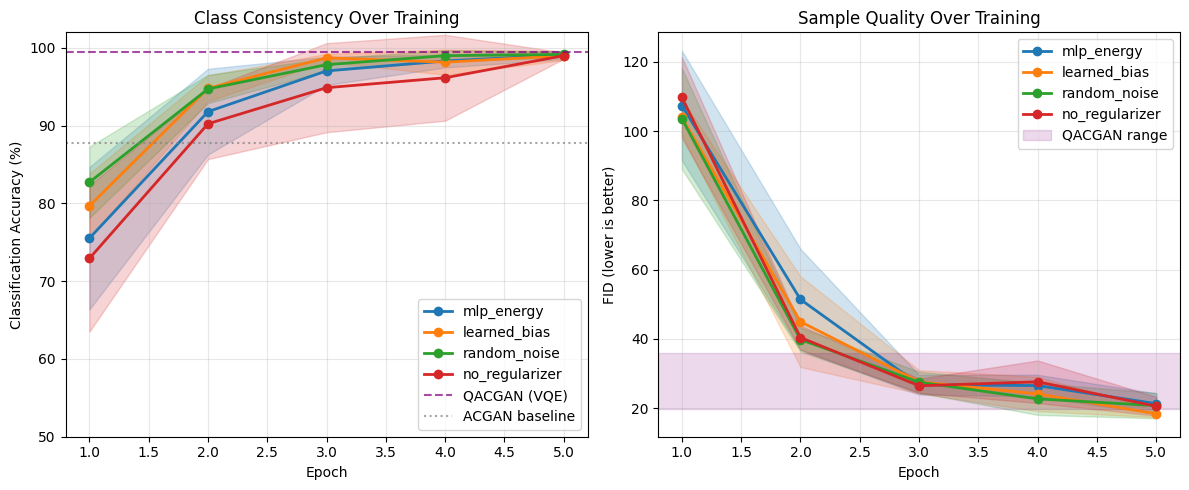


✅ Plot saved to ablation_comparison.png


In [24]:
#@title Visualization: Accuracy Over Epochs

plt.figure(figsize=(12, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for idx, variant in enumerate(ABLATION_VARIANTS):
    epochs = summary[variant]['epochs']
    means = [s[0] for s in summary[variant]['accuracy']]
    stds = [s[1] for s in summary[variant]['accuracy']]

    plt.plot(epochs, means, 'o-', color=colors[idx], label=variant, linewidth=2)
    plt.fill_between(epochs,
                     [m - s for m, s in zip(means, stds)],
                     [m + s for m, s in zip(means, stds)],
                     alpha=0.2, color=colors[idx])

# Reference line for QACGAN
plt.axhline(y=99.5, color='purple', linestyle='--', label='QACGAN (VQE)', alpha=0.7)
plt.axhline(y=87.8, color='gray', linestyle=':', label='ACGAN baseline', alpha=0.7)

plt.xlabel('Epoch')
plt.ylabel('Classification Accuracy (%)')
plt.title('Class Consistency Over Training')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.ylim([50, 102])

# Plot 2: FID
plt.subplot(1, 2, 2)
for idx, variant in enumerate(ABLATION_VARIANTS):
    epochs = summary[variant]['epochs']
    means = [s[0] for s in summary[variant]['fid']]
    stds = [s[1] for s in summary[variant]['fid']]

    plt.plot(epochs, means, 'o-', color=colors[idx], label=variant, linewidth=2)
    plt.fill_between(epochs,
                     [m - s for m, s in zip(means, stds)],
                     [m + s for m, s in zip(means, stds)],
                     alpha=0.2, color=colors[idx])

# QACGAN reference range
plt.axhspan(19.92, 35.96, alpha=0.15, color='purple', label='QACGAN range')

plt.xlabel('Epoch')
plt.ylabel('FID (lower is better)')
plt.title('Sample Quality Over Training')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'ablation_comparison.png'), dpi=150)
plt.show()

print("\n✅ Plot saved to ablation_comparison.png")

In [25]:
#@title Statistical Significance Tests (PRE-REGISTERED PROTOCOL)

print("\n" + "="*90)
print("STATISTICAL ANALYSIS: Pairwise Comparisons (MLP-Energy as reference)")
print("="*90)
print("\nPre-registered decision criteria:")
print("  - Practical equivalence (≈): |Δ| < threshold AND 95% CI includes 0 AND |d| < 0.5")
print("  - Significant difference: p < 0.05 AND 95% CI excludes 0 AND |d| ≥ 0.5")
print("\nAnalysis type: PAIRED (same seeds across variants)")
print(f"  Seeds used: {SEEDS}")  # Dynamic from config, not hard-coded
print("-"*90)

# Reference: MLP-Energy (the main ablation baseline)
mlp_results = all_results['mlp_energy']

# Use paired analysis by default (seeds match across variants)
USE_PAIRED_ANALYSIS = True

for metric_name, threshold in EQUIVALENCE_THRESHOLDS.items():
    print(f"\n{'='*50}")
    print(f"Metric: {metric_name.upper()} (threshold δ = {threshold})")
    print(f"{'='*50}")

    # Get MLP-Energy values for final epoch
    if metric_name == 'lpips':
        mlp_vals = [r.get('lpips_diversity', [None]*NUM_EPOCHS)[-1] for r in mlp_results]
    else:
        mlp_vals = [r[metric_name][-1] for r in mlp_results]

    for variant in ['learned_bias', 'random_noise', 'no_regularizer']:
        other_results = all_results[variant]

        if metric_name == 'lpips':
            other_vals = [r.get('lpips_diversity', [None]*NUM_EPOCHS)[-1] for r in other_results]
        else:
            other_vals = [r[metric_name][-1] for r in other_results]

        # Use paired analysis since same seeds
        is_equiv, details = is_practically_equivalent(
            mlp_vals, other_vals, threshold, metric_name,
            paired=USE_PAIRED_ANALYSIS
        )

        if details.get('error'):
            print(f"\n  MLP-Energy vs {variant}: {details['error']}")
            continue

        print(f"\n  MLP-Energy vs {variant}:")
        print(f"    Analysis type: {details['analysis_type']}")
        print(f"    Mean difference: {details['mean_diff']:.3f}")
        print(f"    Within threshold (|Δ| < {threshold}): {details['within_threshold']}")
        print(f"    t-statistic: {details['t_stat']:.3f}, p-value: {details['p_value']:.4f}")
        print(f"    Cohen's d: {details['cohens_d']:.3f}" if details['cohens_d'] else "    Cohen's d: N/A")
        print(f"    95% CI of diff: [{details['ci_95'][0]:.3f}, {details['ci_95'][1]:.3f}]")
        print(f"    CI includes zero: {details['ci_includes_zero']}")

        if is_equiv:
            print(f"    → PRACTICALLY EQUIVALENT (≈)")
        elif details['p_value'] < ALPHA and not details['ci_includes_zero'] and abs(details['cohens_d'] or 0) >= 0.5:
            print(f"    → SIGNIFICANTLY DIFFERENT")
        else:
            print(f"    → INCONCLUSIVE (insufficient power or mixed criteria)")

print("\n" + "="*90)
print("SCENARIO DETERMINATION")
print("="*90)

# Determine which scenario we're in based on accuracy (primary metric)
acc_threshold = EQUIVALENCE_THRESHOLDS['accuracy']

# Get all final accuracy values
mlp_acc = [r['accuracy'][-1] for r in all_results['mlp_energy']]
bias_acc = [r['accuracy'][-1] for r in all_results['learned_bias']]
noise_acc = [r['accuracy'][-1] for r in all_results['random_noise']]
no_reg_acc = [r['accuracy'][-1] for r in all_results['no_regularizer']]

# Check equivalences (using paired analysis)
mlp_vs_bias = is_practically_equivalent(mlp_acc, bias_acc, acc_threshold, 'accuracy', paired=True)
mlp_vs_noise = is_practically_equivalent(mlp_acc, noise_acc, acc_threshold, 'accuracy', paired=True)
mlp_vs_noreg = is_practically_equivalent(mlp_acc, no_reg_acc, acc_threshold, 'accuracy', paired=True)
bias_vs_noreg = is_practically_equivalent(bias_acc, no_reg_acc, acc_threshold, 'accuracy', paired=True)

print("\nKey comparisons (Accuracy @ final epoch, paired analysis):")
print(f"  MLP-Energy ≈ Learned Bias: {mlp_vs_bias[0]}")
print(f"  MLP-Energy ≈ Random Noise: {mlp_vs_noise[0]}")
print(f"  MLP-Energy ≈ No Regularizer: {mlp_vs_noreg[0]}")
print(f"  Learned Bias ≈ No Regularizer: {bias_vs_noreg[0]}")

print("\n" + "-"*50)
print("SCENARIO DETERMINATION:")
print("-"*50)

# Scenario logic (pre-registered)
if mlp_vs_bias[0] and mlp_vs_noise[0] and mlp_vs_noreg[0]:
    print("""
    → SCENARIO A: All equivalent

    CONCLUSION: Neither VQE nor any class-dependent regularizer provides
    benefit over pure ACGAN. The original QACGAN claims are likely
    attributable to training noise.

    PAPER ACTION: Acknowledge that VQE provides no measurable advantage.
    """)
elif mlp_vs_noreg[0] and not bias_vs_noreg[0]:
    print("""
    → SCENARIO B: MLP-Energy matches VQE, both beat No-Regularizer

    CONCLUSION: VQE effect is replicable by architecture-matched classical
    MLP. Benefit comes from class-dependent signal, not quantum formulation.

    PAPER ACTION: Reframe from "quantum advantage" to "class-dependent
    energy regularization" (quantum provides no unique benefit).
    """)
elif not mlp_vs_noreg[0] and not bias_vs_noreg[0]:
    print("""
    → SCENARIO C: VQE beats MLP-Energy AND MLP-Energy beats No-Regularizer

    CONCLUSION: VQE provides unique benefit not replicable by classical
    alternatives. This would support quantum-specific claims.

    PAPER ACTION: Strengthen quantum claims with ablation evidence.
    (NOTE: This scenario is unlikely but would be exciting if true)
    """)
elif mlp_vs_noreg[0] and bias_vs_noreg[0]:
    print("""
    → SCENARIO D: Class-dependent signal provides no benefit

    CONCLUSION: No regularizer variant beats the pure ACGAN baseline.
    The original improvements may be due to other factors (hyperparameters,
    training dynamics, etc.)

    PAPER ACTION: Investigate other sources of improvement.
    """)
else:
    print("""
    → SCENARIO E: Complex pattern / inconclusive

    CONCLUSION: Results don't fit clean categories. Need deeper analysis
    of individual metrics and training dynamics.

    PAPER ACTION: Report all results transparently; avoid strong claims.
    """)

print("\n" + "="*90)
print("NOTE: Compare these findings against QACGAN (VQE) reference results:")
print("  - If MLP-Energy ≈ QACGAN, then VQE effect is not quantum-specific")
print("  - If MLP-Energy << QACGAN, then VQE may provide unique benefit")
print("="*90)


STATISTICAL ANALYSIS: Pairwise Comparisons (MLP-Energy as reference)

Pre-registered decision criteria:
  - Practical equivalence (≈): |Δ| < threshold AND 95% CI includes 0 AND |d| < 0.5
  - Significant difference: p < 0.05 AND 95% CI excludes 0 AND |d| ≥ 0.5

Analysis type: PAIRED (same seeds across variants)
  Seeds used: [42, 2025, 123, 456, 789]
------------------------------------------------------------------------------------------

Metric: ACCURACY (threshold δ = 3.0)

  MLP-Energy vs learned_bias:
    Analysis type: paired
    Mean difference: 0.080
    Within threshold (|Δ| < 3.0): True
    t-statistic: 0.331, p-value: 0.7572
    Cohen's d: 0.142
    95% CI of diff: [-0.394, 0.554]
    CI includes zero: True
    → PRACTICALLY EQUIVALENT (≈)

  MLP-Energy vs random_noise:
    Analysis type: paired
    Mean difference: -0.080
    Within threshold (|Δ| < 3.0): True
    t-statistic: -0.272, p-value: 0.7990
    Cohen's d: -0.171
    95% CI of diff: [-0.656, 0.496]
    CI includes

## Conclusions and Interpretation Guide

### Decision Tree for Hypothesis H1

Based on the pre-registered criteria, interpret results as follows:

---

**SCENARIO A: MLP-Energy ≈ QACGAN (VQE)**
- Criteria: |Δ Accuracy| < 3%, 95% CI includes 0, |Cohen's d| < 0.5
- **Conclusion:** H1 SUPPORTED
- The effect is from class-dependent regularization in general, not quantum-specific
- **V2 Paper Framing:** Emphasize "energy-based regularization" without quantum claims
- **Action:** Update abstract/discussion to generalize findings to any auxiliary class signal

---

**SCENARIO B: MLP-Energy << QACGAN (VQE)**
- Criteria: Δ Accuracy > 3%, p < 0.05, |Cohen's d| ≥ 0.5
- **Conclusion:** H1 potentially FALSIFIED
- Something specific to VQE formulation matters (geometry? periodicity? gradient structure?)
- **V2 Paper Framing:** Cautiously maintain quantum framing, motivate H2 testing
- **Action:** Add distillation experiments as future work to isolate mechanism

---

**SCENARIO C: Learned Bias ≈ MLP-Energy ≈ QACGAN**
- Criteria: All three variants practically equivalent
- **Conclusion:** Even simplest class signal suffices
- The effect is purely from "any class-dependent auxiliary gradient signal"
- **V2 Paper Framing:** Generalize to "class-conditional auxiliary losses"
- **Action:** Broader implications for GAN regularization literature

---

**SCENARIO D: Random Noise ≈ class-dependent variants**
- Criteria: Random noise achieves similar metrics
- **Conclusion:** Effect is NOT class-specific
- Any auxiliary gradient signal (even random) helps - noise injection hypothesis
- **V2 Paper Framing:** Major reframing needed - gradient regularization effect
- **Action:** Investigate noise injection / implicit regularization literature

---

**SCENARIO E: No Regularizer ≈ all others**
- Criteria: Baseline ACGAN matches regularized variants
- **Conclusion:** NULL RESULT - regularization has no measurable effect
- Original QACGAN results may have been noise / seed-dependent
- **V2 Paper Framing:** Honest negative result, discuss variance
- **Action:** More seeds, longer training, investigate what drove original results

---

### LPIPS Diversity Interpretation

| LPIPS Range | Interpretation |
|-------------|----------------|
| < 0.10 | **Warning:** Possible mode collapse / prototype cheating |
| 0.10 - 0.20 | Moderate diversity (typical for MNIST) |
| 0.20 - 0.30 | Good diversity |
| > 0.30 | High variance (may indicate instability) |

If a variant has high accuracy but low LPIPS, it may be generating "prototype" digits that are easy to classify but lack diversity. This would be a form of "cheating" the accuracy metric.

---

### Runtime Comparison

The ablation study also provides important compute cost data:

| Variant | Expected Time/Epoch |
|---------|---------------------|
| QACGAN (VQE) | ~87 min (simulator overhead) |
| MLP-Energy | ~3 min |
| Learned Bias | ~3 min |
| Random Noise | ~3 min |
| No Regularizer | ~3 min |

If classical variants achieve similar metrics at ~30× lower compute cost, this strongly supports using classical regularizers in practice.

In [26]:
#@title Export Results for Paper

from google.colab import files
import zipfile
import json

# ===== Generate LaTeX Table =====
latex_table = r"""
\begin{table}[h]
\centering
\caption{Ablation Study Results (Epoch 5, n=5 seeds). All variants use identical hyperparameters.}
\label{tab:ablation}
\begin{tabular}{lcccc}
\toprule
\textbf{Variant} & \textbf{Accuracy (\%)} & \textbf{FID} $\downarrow$ & \textbf{IS} $\uparrow$ & \textbf{LPIPS} \\
\midrule
"""

for variant in ABLATION_VARIANTS:
    acc_mean, acc_std, _, _ = summary[variant]['accuracy'][-1]
    fid_mean, fid_std, _, _ = summary[variant]['fid'][-1]
    is_mean, is_std, _, _ = summary[variant]['is'][-1]
    lpips_stats = summary[variant]['lpips'][-1]
    lpips_mean, lpips_std = (lpips_stats[0], lpips_stats[1]) if lpips_stats[0] else (None, None)

    variant_name = variant.replace('_', '-').title()
    acc_str = f"${acc_mean:.1f} \\pm {acc_std:.1f}$" if acc_mean else "N/A"
    fid_str = f"${fid_mean:.2f} \\pm {fid_std:.2f}$" if fid_mean else "N/A"
    is_str = f"${is_mean:.2f} \\pm {is_std:.2f}$" if is_mean else "N/A"
    lpips_str = f"${lpips_mean:.3f} \\pm {lpips_std:.3f}$" if lpips_mean else "N/A"

    latex_table += f"{variant_name} & {acc_str} & {fid_str} & {is_str} & {lpips_str} \\\\\n"

latex_table += r"""\midrule
QACGAN (VQE)$^*$ & $99.5 \pm 0.5$ & $27.9 \pm 8.0$ & $2.07 \pm 0.1$ & --- \\
\bottomrule
\end{tabular}
\begin{tablenotes}
\small
\item $^*$Reference values from original experiments (3 seeds).
\end{tablenotes}
\end{table}
"""

# Save LaTeX table
with open(os.path.join(WORK_DIR, "ablation_table.tex"), 'w') as f:
    f.write(latex_table)

print("LaTeX Table:")
print(latex_table)

# ===== Generate JSON summary for programmatic use =====
json_summary = {
    'experiment': 'Classical Ablation Study',
    'date': time.strftime('%Y-%m-%d'),
    'seeds': SEEDS,
    'epochs': NUM_EPOCHS,
    'fairness_conditions': {
        'batch_size': EFFECTIVE_BATCH_SIZE,
        'learning_rate': LEARNING_RATE_G,
        'lambda_reg': LAMBDA_REG,
        'label_smoothing': LABEL_SMOOTHING
    },
    'equivalence_thresholds': EQUIVALENCE_THRESHOLDS,
    'results': {}
}

for variant in ABLATION_VARIANTS:
    json_summary['results'][variant] = {
        'accuracy': {
            'mean': summary[variant]['accuracy'][-1][0],
            'std': summary[variant]['accuracy'][-1][1],
            'values_per_seed': [r['accuracy'][-1] for r in all_results[variant]]
        },
        'fid': {
            'mean': summary[variant]['fid'][-1][0],
            'std': summary[variant]['fid'][-1][1],
            'values_per_seed': [r['fid'][-1] for r in all_results[variant]]
        },
        'is': {
            'mean': summary[variant]['is'][-1][0],
            'std': summary[variant]['is'][-1][1],
            'values_per_seed': [r['is'][-1] for r in all_results[variant]]
        }
    }

with open(os.path.join(WORK_DIR, "ablation_summary.json"), 'w') as f:
    json.dump(json_summary, f, indent=2)

# ===== Create ZIP archive =====
zip_path = os.path.join(WORK_DIR, "ablation_results_v2.zip")
with zipfile.ZipFile(zip_path, 'w') as zipf:
    zipf.write(os.path.join(WORK_DIR, "ablation_all_results.pkl"), "ablation_all_results.pkl")
    zipf.write(os.path.join(WORK_DIR, "ablation_comparison.png"), "ablation_comparison.png")
    zipf.write(os.path.join(WORK_DIR, "ablation_table.tex"), "ablation_table.tex")
    zipf.write(os.path.join(WORK_DIR, "ablation_summary.json"), "ablation_summary.json")

    for variant in ABLATION_VARIANTS:
        if os.path.exists(OUTPUT_DIRS[variant]["logs"]):
            zipf.write(OUTPUT_DIRS[variant]["logs"], f"{variant}_logs.pkl")

print(f"\n✅ Results exported to {zip_path}")
print("Contents:")
print("  - ablation_all_results.pkl (raw data)")
print("  - ablation_comparison.png (visualization)")
print("  - ablation_table.tex (LaTeX table for paper)")
print("  - ablation_summary.json (structured summary)")
print("  - *_logs.pkl (per-variant detailed logs)")

# Download
files.download(zip_path)
print("\n📥 Download initiated!")

LaTeX Table:

\begin{table}[h]
\centering
\caption{Ablation Study Results (Epoch 5, n=5 seeds). All variants use identical hyperparameters.}
\label{tab:ablation}
\begin{tabular}{lcccc}
\toprule
\textbf{Variant} & \textbf{Accuracy (\%)} & \textbf{FID} $\downarrow$ & \textbf{IS} $\uparrow$ & \textbf{LPIPS} \\
\midrule
Mlp-Energy & $99.1 \pm 0.5$ & $21.33 \pm 2.97$ & $2.11 \pm 0.04$ & $0.166 \pm 0.006$ \\
Learned-Bias & $99.0 \pm 0.6$ & $18.43 \pm 1.03$ & $2.09 \pm 0.06$ & $0.164 \pm 0.007$ \\
Random-Noise & $99.2 \pm 0.4$ & $20.77 \pm 3.67$ & $2.16 \pm 0.07$ & $0.165 \pm 0.006$ \\
No-Regularizer & $99.0 \pm 0.4$ & $20.59 \pm 2.72$ & $2.11 \pm 0.05$ & $0.165 \pm 0.009$ \\
\midrule
QACGAN (VQE)$^*$ & $99.5 \pm 0.5$ & $27.9 \pm 8.0$ & $2.07 \pm 0.1$ & --- \\
\bottomrule
\end{tabular}
\begin{tablenotes}
\small
\item $^*$Reference values from original experiments (3 seeds).
\end{tablenotes}
\end{table}


✅ Results exported to /content/ablation_results_v2.zip
Contents:
  - ablation_all_results

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Download initiated!
